In [1]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from eci.plots import (
    compute_vote_shares,
    plot_preference,
    plot_voting_system_comparison,
)
from eci.voting_system.decisions import (
    response_function,
    response_function_logpdf,
    response_function_pref,
)
from eci.voting_system.plurality import _vote_plurality
from eci.voting_system.quadratic import _vote_quadratic

rng = jax.random.key(0)

In [ ]:
# --- candidates & agents -----------------------------------------------------
n_candidates = 5
n_pref = 3

mean_precision = 0.65
candidate_means = jnp.tile(jnp.linspace(0.0, 2.0, n_candidates)[:, None], (1, n_pref))
candidate_precs = jnp.full((n_candidates, n_pref), mean_precision)

agents_per_cluster, sigma = 1, 0.08
cluster_centers = candidate_means[jnp.array([0, 2, 4])]

key = jax.random.PRNGKey(0)
k_mean, k_belief = jax.random.split(key)
pref_means = jnp.concatenate(
    [
        c + sigma * jax.random.normal(k, (agents_per_cluster, n_pref))
        for c, k in zip(cluster_centers, jax.random.split(k_mean, 3))
    ]
)
n_agents = pref_means.shape[0]
belief_means = pref_means + 0.05 * jax.random.normal(k_belief, pref_means.shape)

# --- 2x2 factorial: preference precision x belief precision ------------------
PREF_HIGH, PREF_LOW = 5.0, 0.3
BEL_HIGH, BEL_LOW = 8.0, 0.5


def make_data(pref_prec: float, bel_prec: float) -> dict:
    """Build a `data` dict for the 2x2 (pref precision × belief precision) grid.

    Both precisions are broadcast to shape ``(n_agents, n_pref)``; means and
    candidates are reused across the 4 cells of the factorial.
    """

    def full(p: float) -> jnp.ndarray:
        return jnp.full((n_agents, n_pref), p)

    return {
        "beliefs": {"mean": belief_means, "precision": full(bel_prec)},
        "preferences": {"mean": pref_means, "precision": full(pref_prec)},
        "candidates": {"mean": candidate_means, "precision": candidate_precs},
    }


datasets = {
    "pl_bl": make_data(PREF_LOW, BEL_LOW),
    "pl_bh": make_data(PREF_LOW, BEL_HIGH),
    "ph_bl": make_data(PREF_HIGH, BEL_LOW),
    "ph_bh": make_data(PREF_HIGH, BEL_HIGH),
}

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_48966/2260083222.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


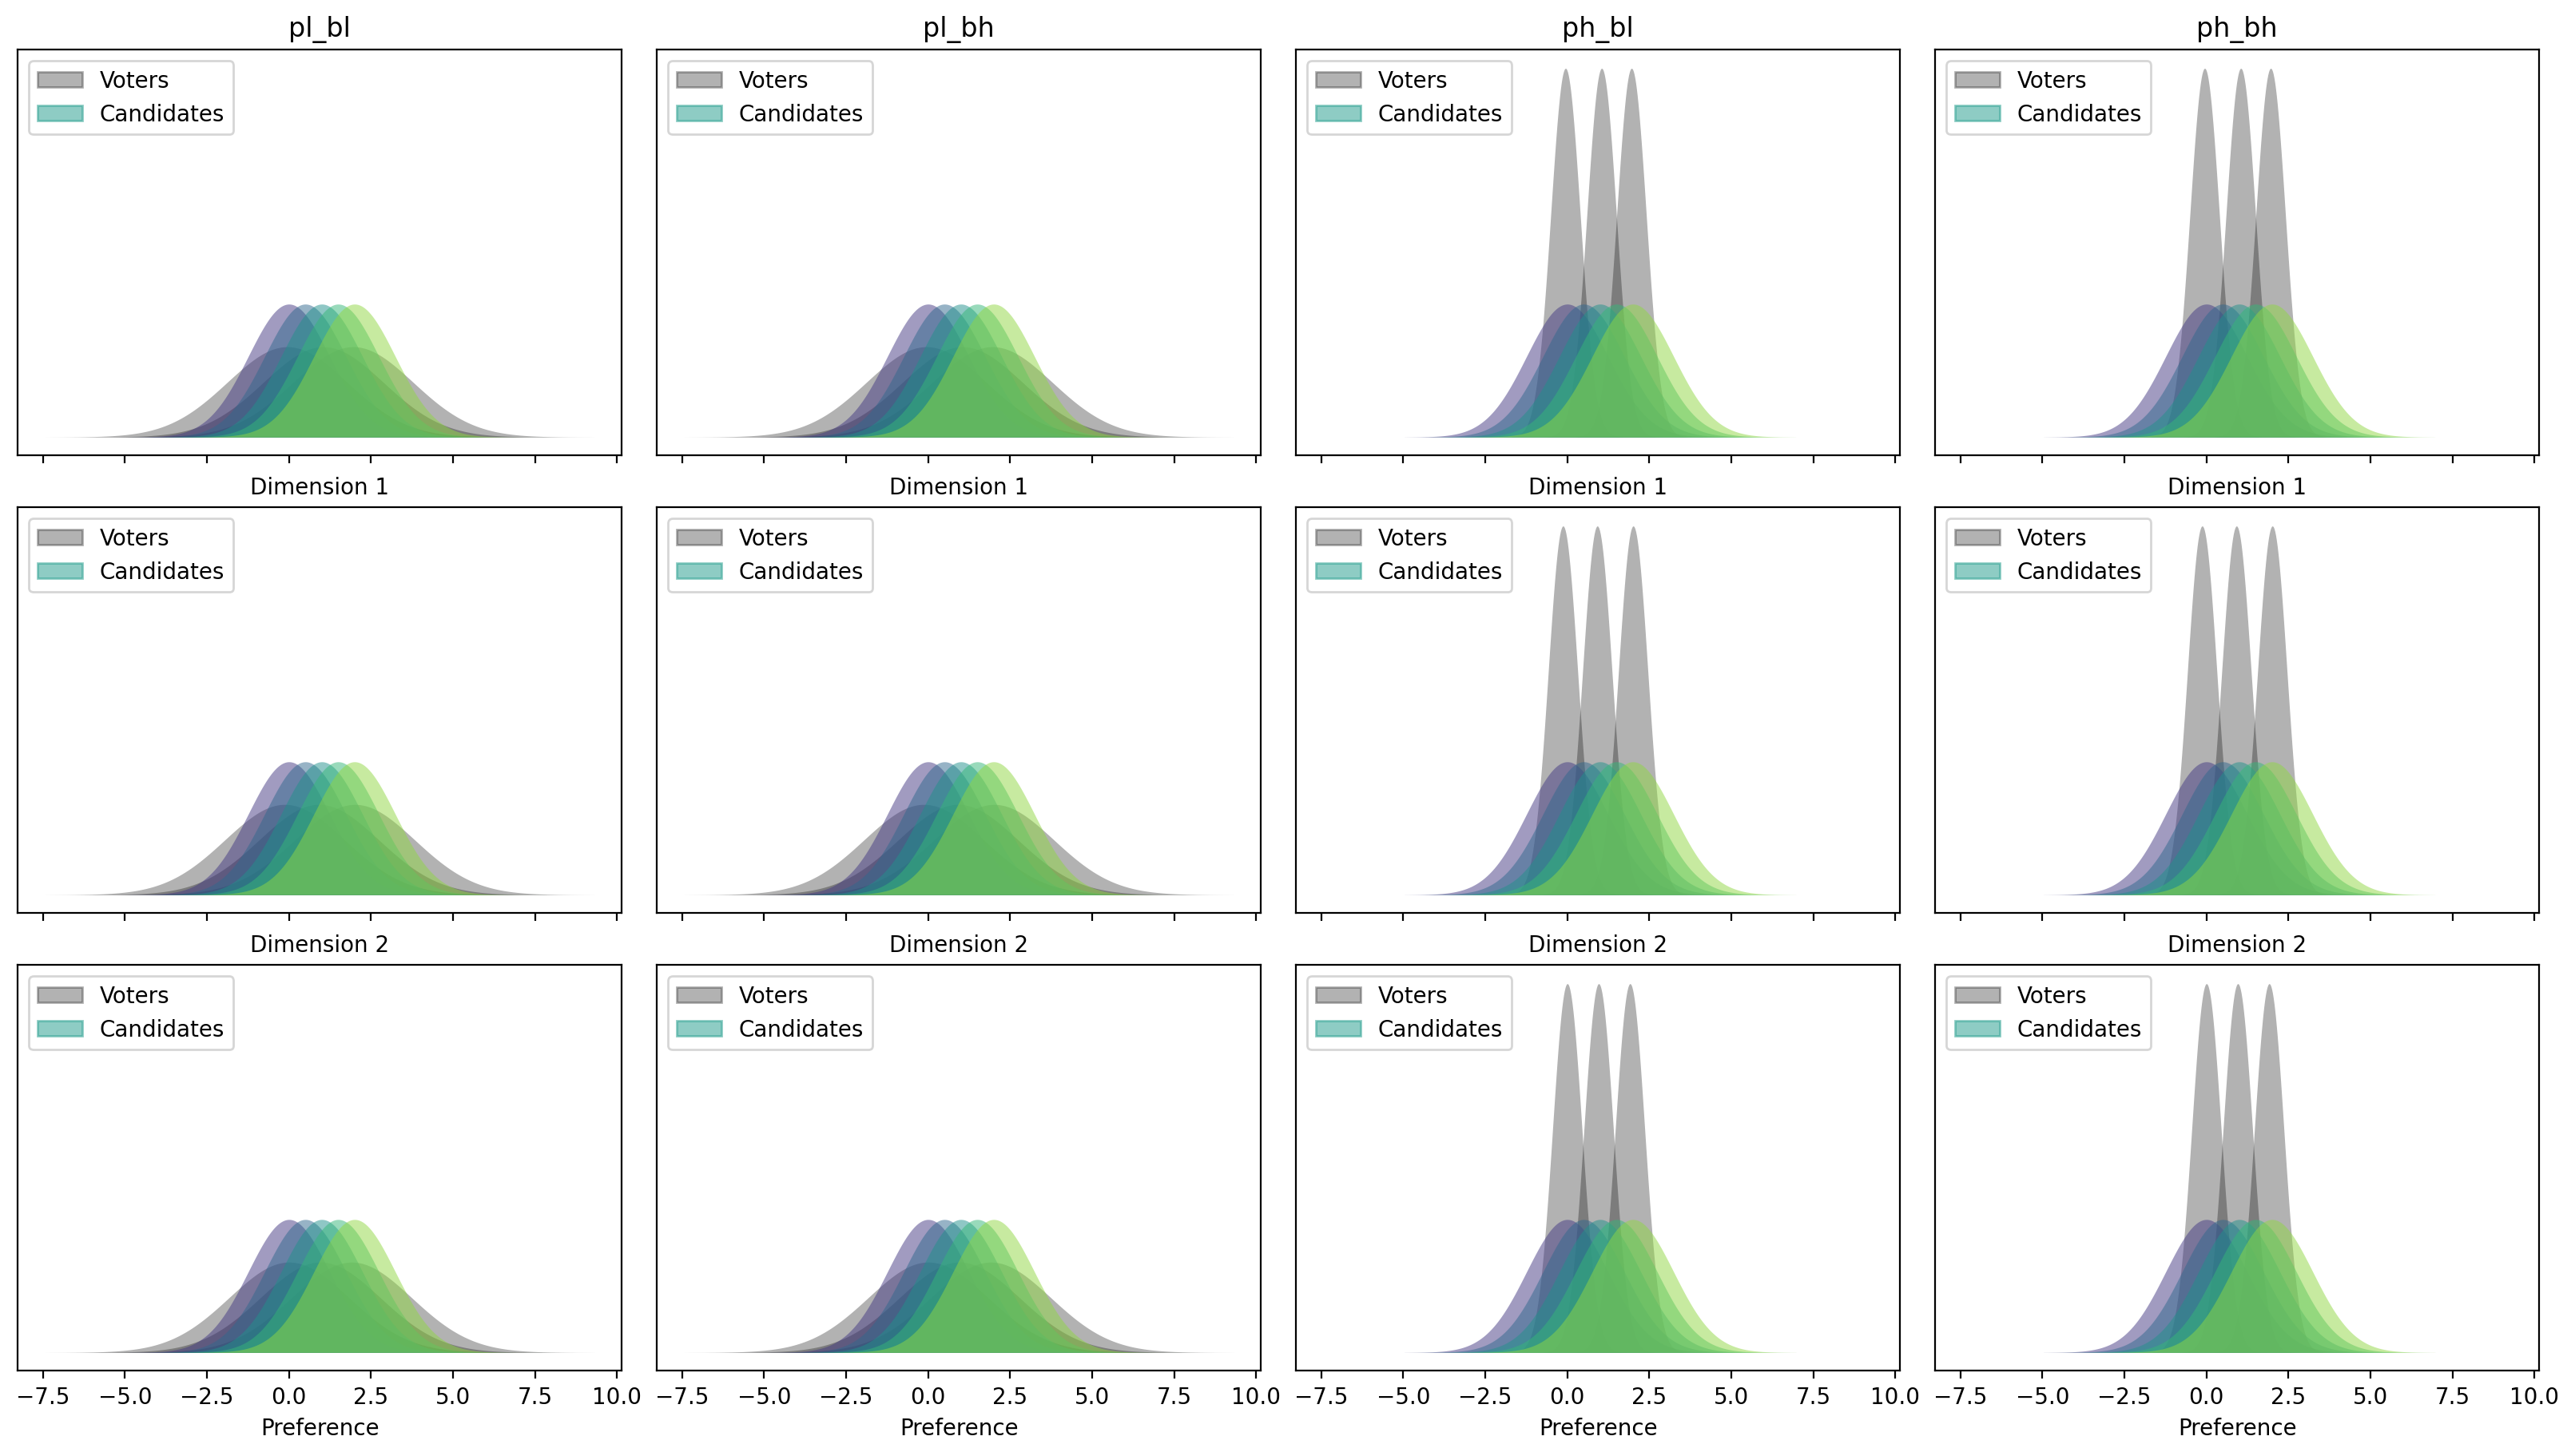

In [3]:
# One column per dataset, one row per preference dimension.
fig, axes = plt.subplots(
    n_pref,
    len(datasets),
    figsize=(4 * len(datasets), 3 * n_pref),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_2d(axes)
for c, (name, data) in enumerate(datasets.items()):
    plot_preference(data, ax_array=axes[:, c])
    axes[0, c].set_title(name)
fig.show()

In [4]:
# --- run all simulations: voting x response_fn x dataset ---------------------
response_fns = {
    "pref_fn": response_function_pref,
    "rf": response_function,
    "logpdf": response_function_logpdf,
}
voting_systems = {"Plurality": _vote_plurality, "Quadratic": _vote_quadratic}
n_simulations = 100

# Share sim_keys across datasets within each (vote, fn) cell so that the only
# source of variation across datasets is τ_p / τ_b themselves.
stacked = {}
for vote_name, vote_fn in voting_systems.items():
    for fn_name, fn in response_fns.items():
        rng, sub = jax.random.split(rng)
        sim_keys = jax.random.split(sub, n_simulations)
        for ds_name, data in datasets.items():
            stacked[(vote_name, fn_name, ds_name)] = jax.vmap(
                lambda k, d=data, f=fn, v=vote_fn: v(d, f, k)
            )(sim_keys)

row_keys = [(v, f) for v in voting_systems for f in response_fns]
col_keys = list(datasets.keys())

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_48966/2902794181.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


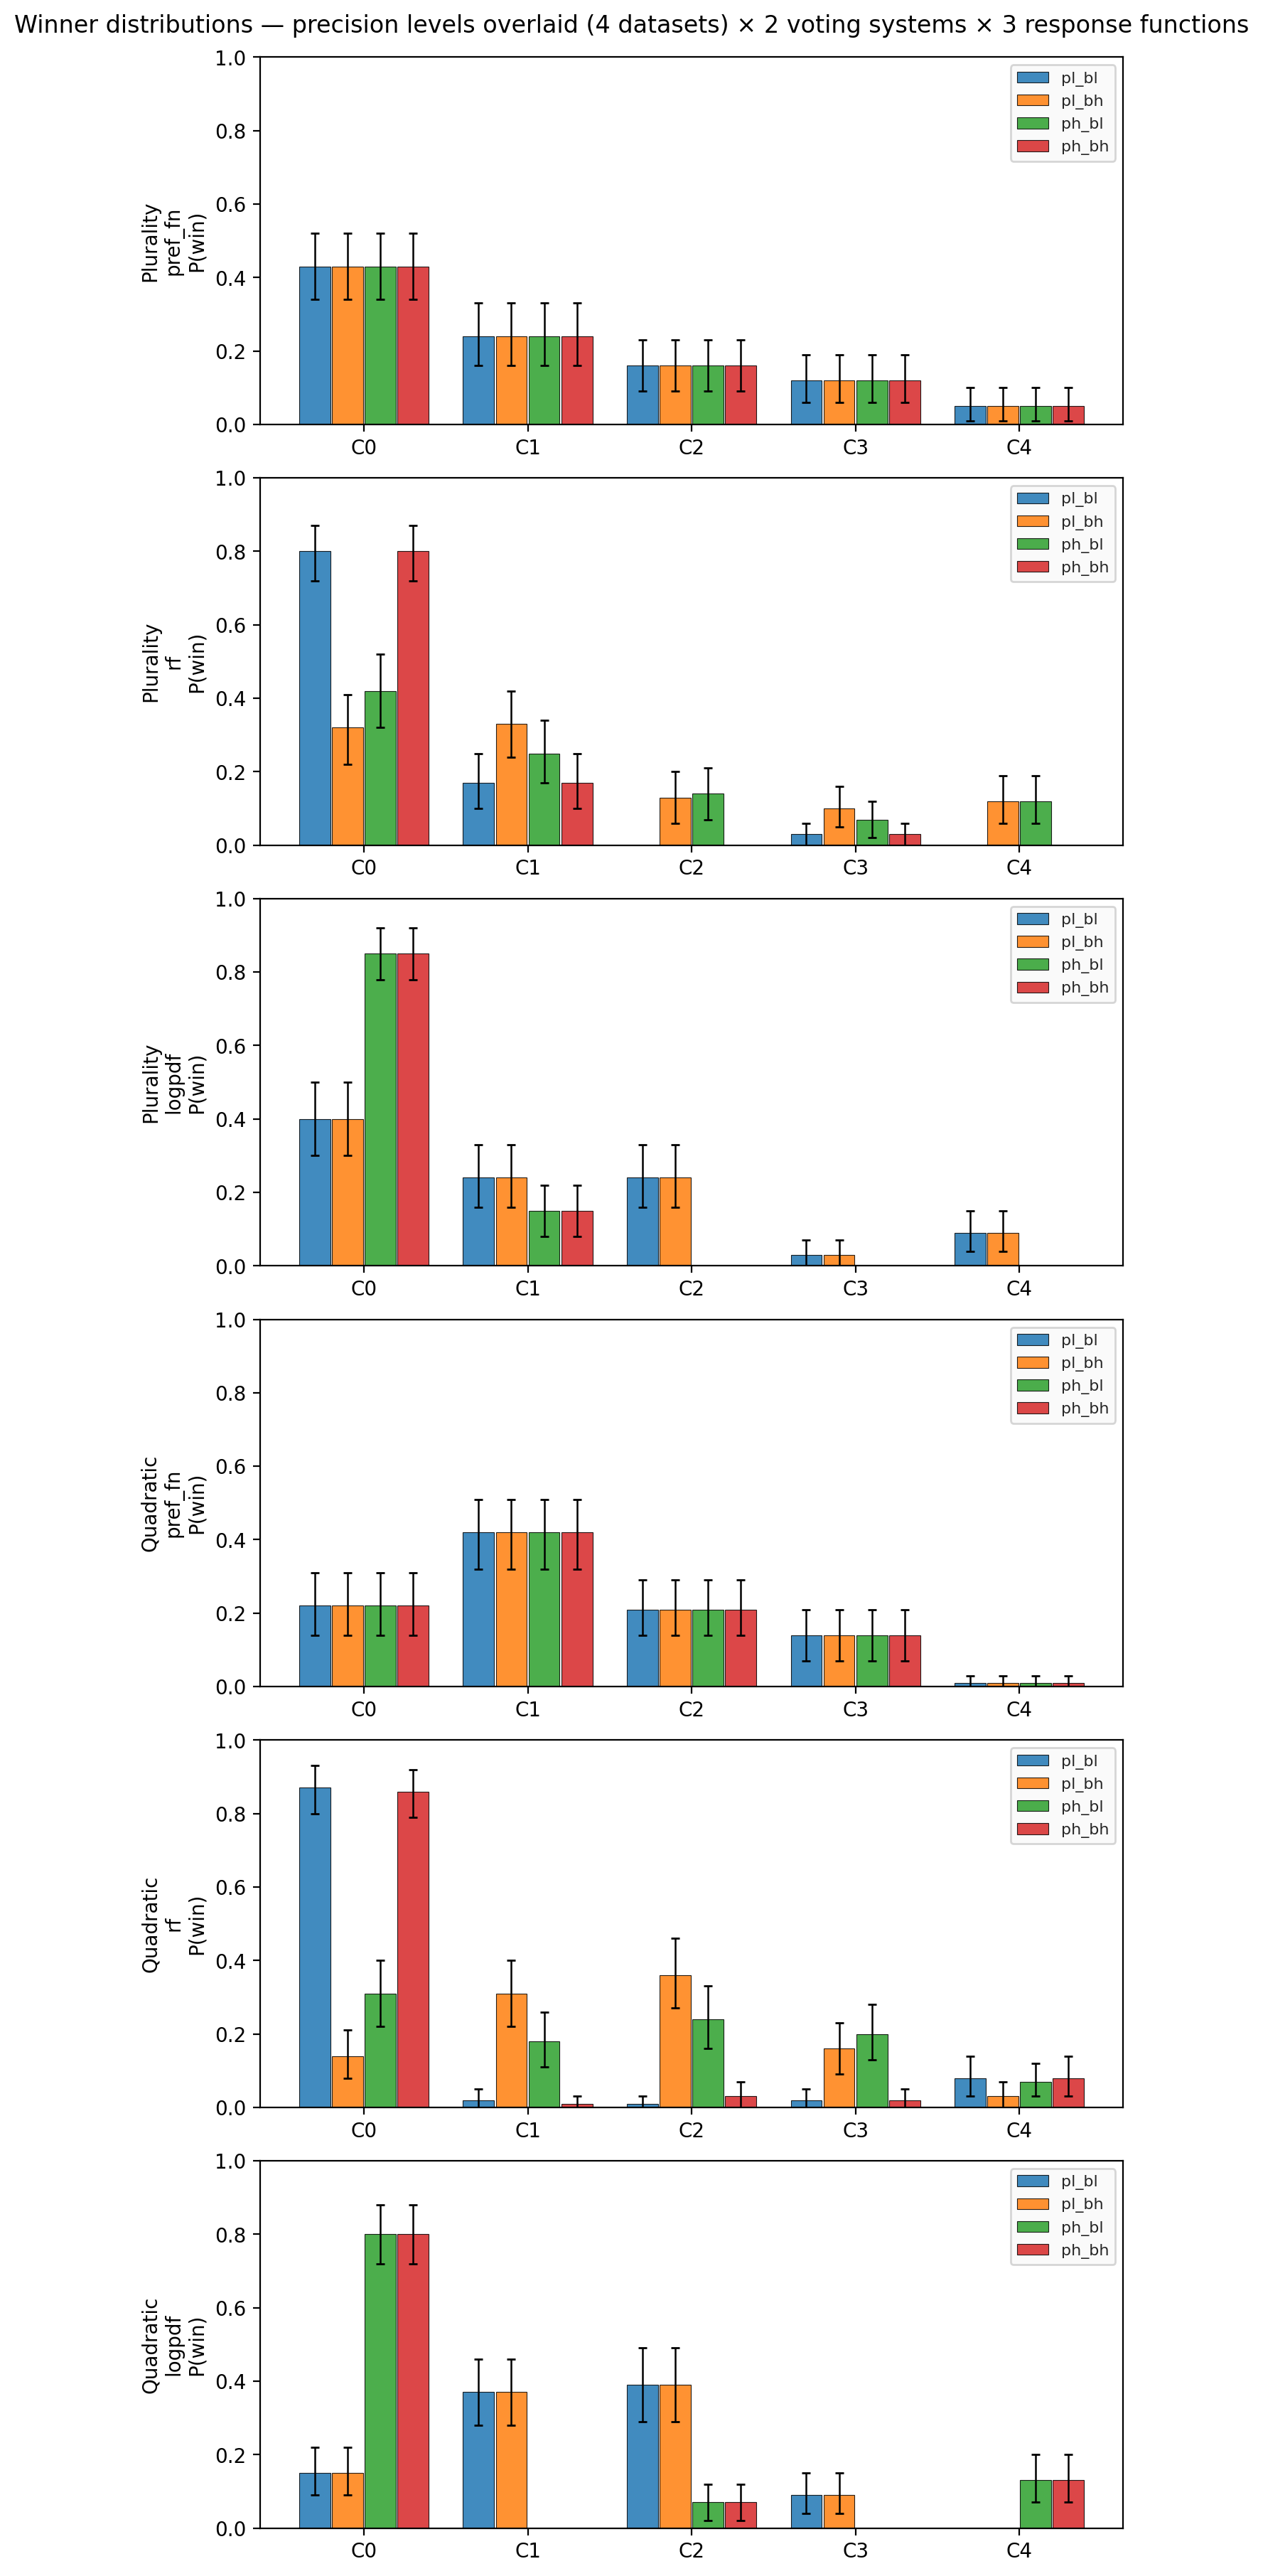

In [ ]:
# --- winner distributions: one panel per (voting, response_fn) --------------
# All 4 datasets (pl_bl, pl_bh, ph_bl, ph_bh) overlaid as grouped colored bars.
from eci.plots import plot_winner_distribution_grouped

fig, axes = plt.subplots(
    len(row_keys),
    1,
    figsize=(7, 3 * len(row_keys)),
    sharey=True,
    constrained_layout=True,
)
for r, (vote_name, fn_name) in enumerate(row_keys):
    winners_by_ds = {
        ds_name: np.asarray(stacked[(vote_name, fn_name, ds_name)]["winner"])
        for ds_name in col_keys
    }
    plot_winner_distribution_grouped(
        winners_by_ds,
        n_candidates=n_candidates,
        ax=axes[r],
    )
    axes[r].set_ylabel(f"{vote_name}\n{fn_name}\nP(win)")
fig.suptitle("Winner distributions — precision levels")
fig.show()

/var/folders/td/5r8mr8t14cn_c4w5c8ty48lw0000gn/T/ipykernel_48966/2540272636.py:24: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


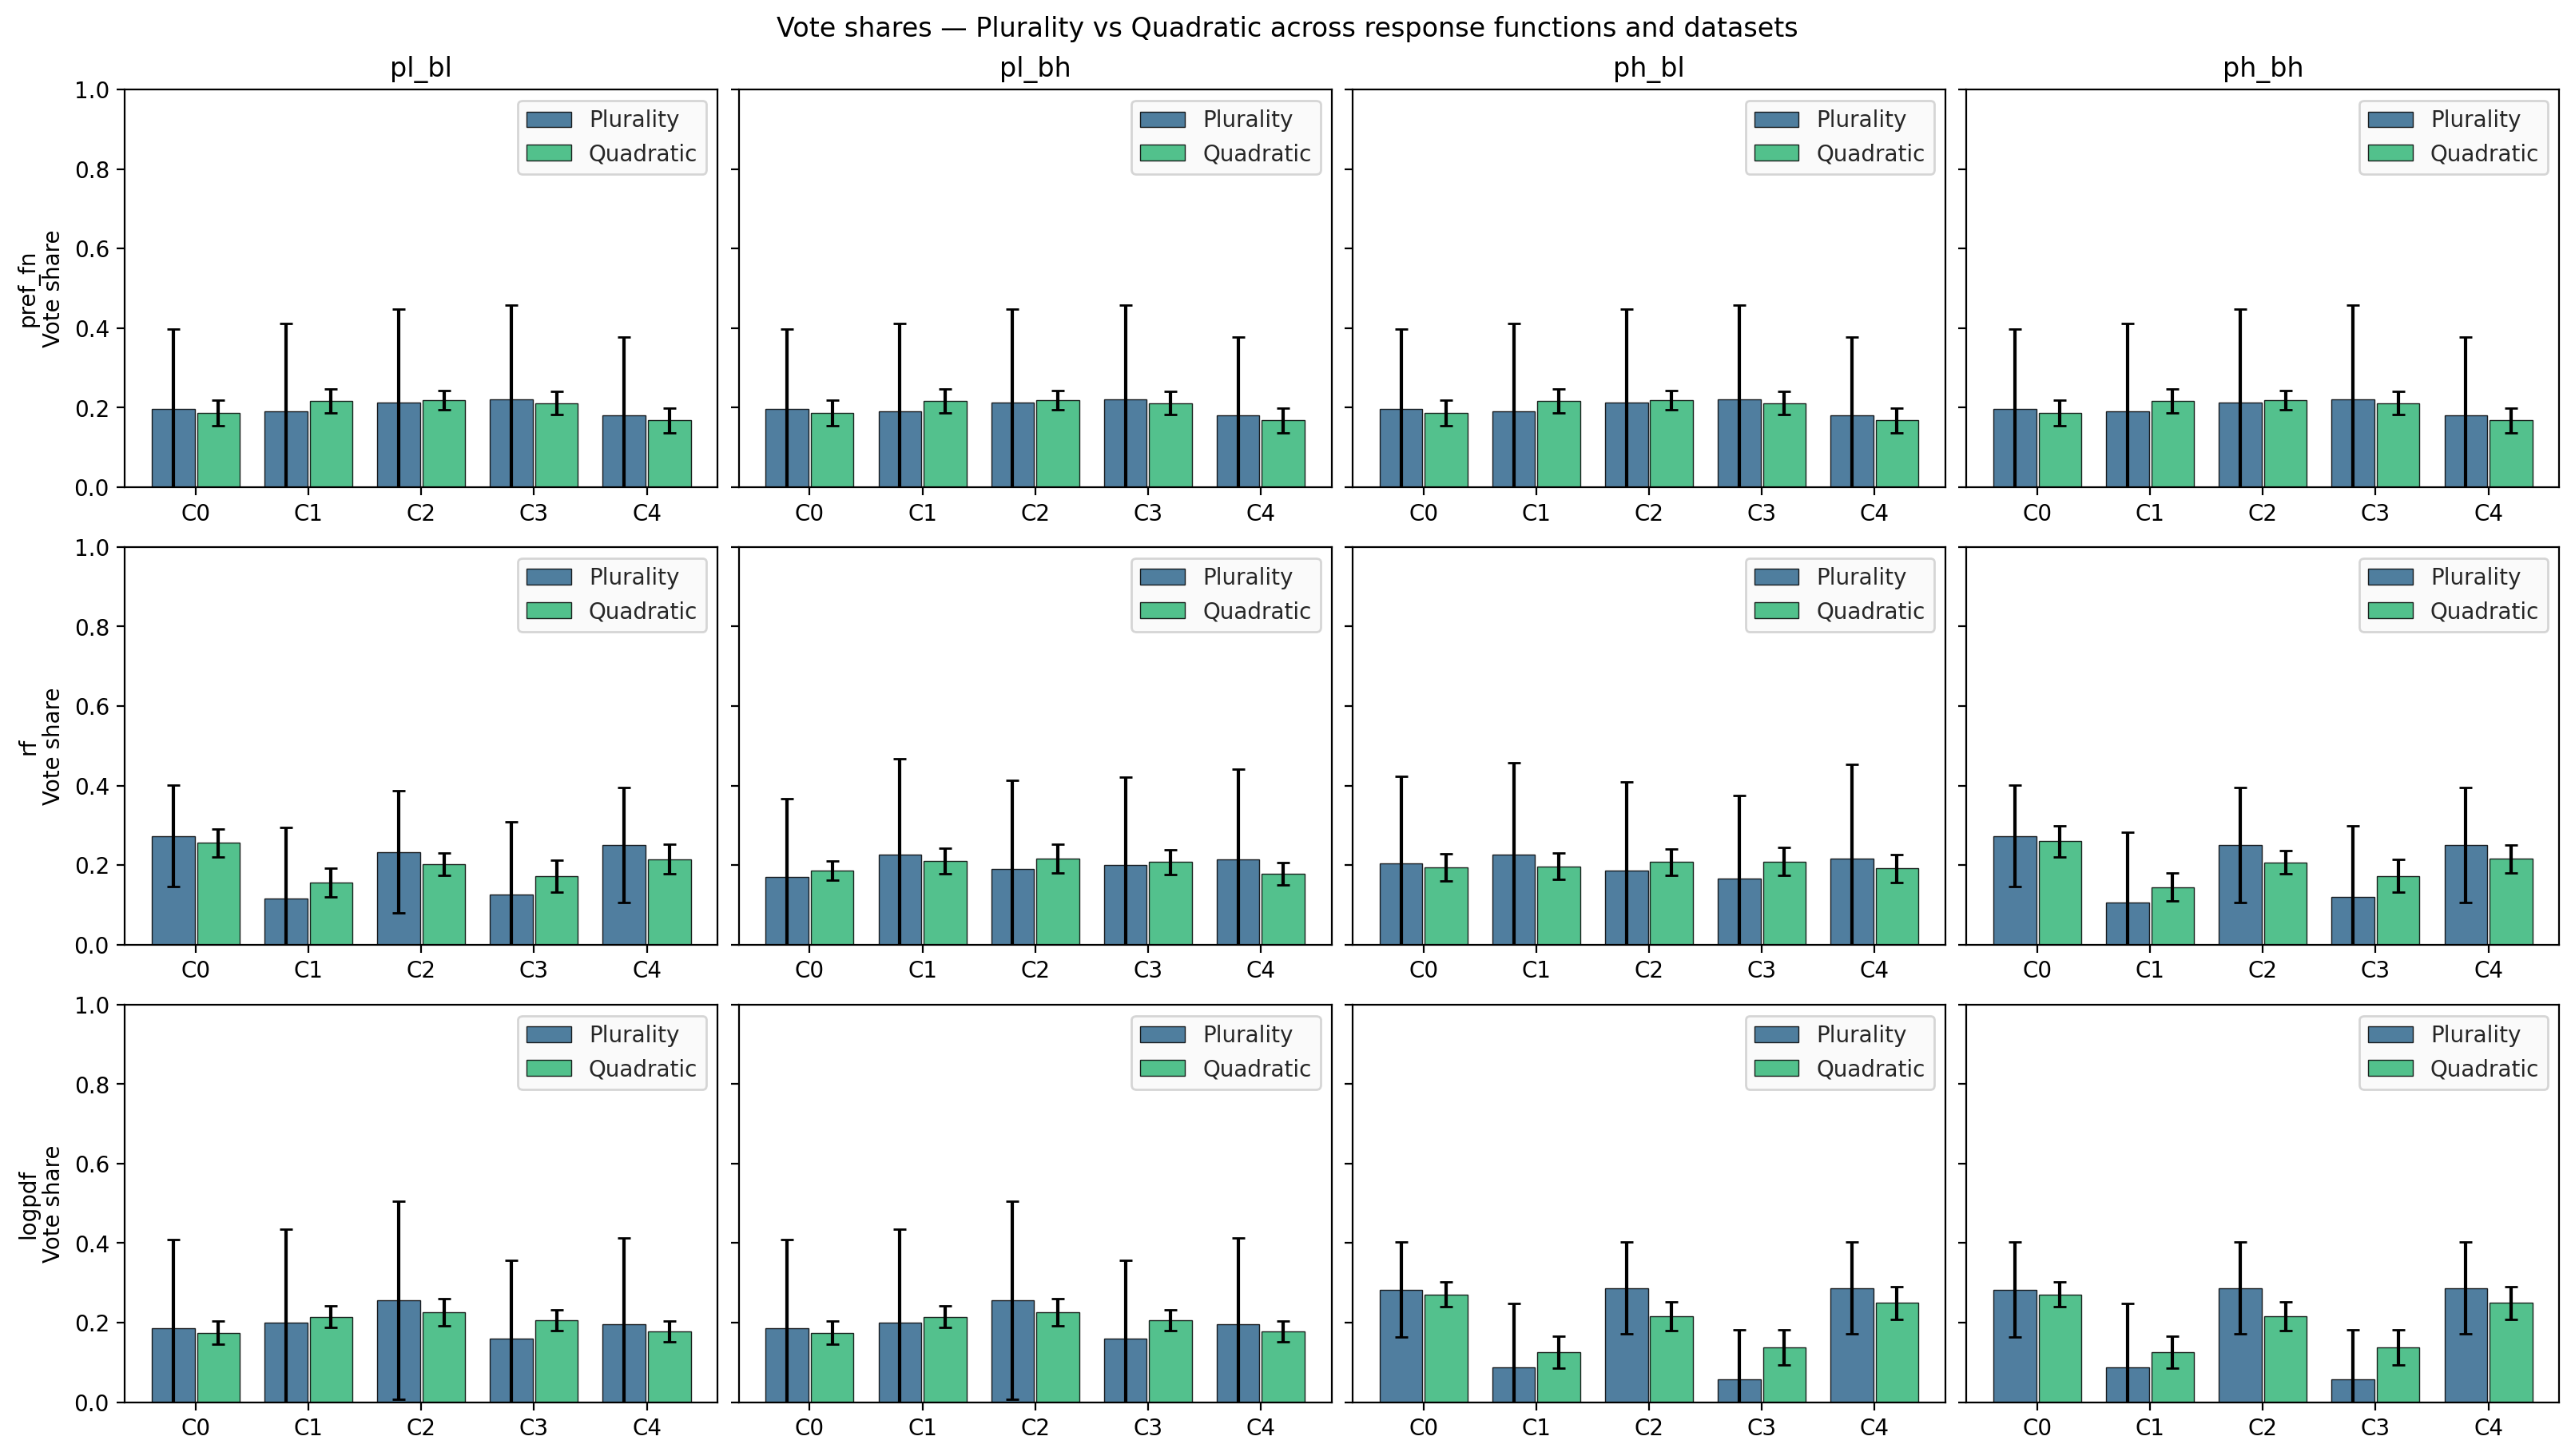

In [6]:
# --- vote shares: one panel per (response_fn, dataset), compare voting systems
fig, axes = plt.subplots(
    len(response_fns),
    len(col_keys),
    figsize=(4 * len(col_keys), 3 * len(response_fns)),
    sharey=True,
    constrained_layout=True,
)
axes = np.atleast_2d(axes)
for r, fn_name in enumerate(response_fns):
    for c, ds_name in enumerate(col_keys):
        shares_by_system = {
            v: compute_vote_shares(stacked[(v, fn_name, ds_name)], n_candidates)
            for v in voting_systems
        }
        plot_voting_system_comparison(shares_by_system, ax=axes[r, c])
        axes[r, c].set_title(ds_name if r == 0 else "")
    axes[r, 0].set_ylabel(f"{fn_name}\nVote share")
for ax in axes[:, 1:].ravel():
    ax.set_ylabel("")
fig.suptitle(
    "Vote shares — Plurality vs Quadratic across response functions and datasets"
)
fig.show()